In [1]:
import ratinabox
from ratinabox.Agent import Agent
from ratinabox.Neurons import PlaceCells
from ratinabox.contribs.NeuralNetworkNeurons import NeuralNetworkNeurons #for the Actor and Critic
from ratinabox.contribs.TaskEnvironment import (SpatialGoalEnvironment, SpatialGoal, Reward)

#misc
import torch 
import numpy as np 
from gymnasium.spaces import Box
from tqdm import tqdm
import time
import random
import seaborn as sns
import pandas as pd
from typing import List, Union, Optional, Tuple
import pickle

from plotting_utils import *
from base_actor_critic import *
from training_utils import *

In [2]:
#TASK CONSTANTS
DT = 0.1 # Time step
T_TIMEOUT = 15 # Time out
GOAL_POS = np.array([0.5, 0.5]) # Goal position
WALL = None
# WALL = [[0.8, 0.0], [0.8, 0.8]]
GOAL_RADIUS = 0.1
REWARD = 1 # Reward
REWARD_DURATION = 1 # Reward duration

#LEARNING CONSTANTS
TAU = 5 # Discount time horizon
TAU_E = 5 # Eligibility trace time horizon
ETA = 0.01 # Learning rate 
N_EPISODES = 5000 # Number of episodes
L2 = 0.000 # L2 regularization
torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

In [3]:
def create_experiment(
    dt=0.1,
    t_timeout=15,
    goal_pos=np.array([0.9, 0.9]),
    goal_radius=0.1,
    reward_val=1,
    reward_duration=1,
    wall=None,
    n_placecells=50,
    fta_eta=0.01,
    eta = 0.01,
    l2=0.0,
    tau=5,
    tau_e=5,
    actor_fta_post=[2],
    critic_fta_post=[1],
):
    """Returns a fresh environment, agent, place cells, actor, critic"""
    
    # --- Environment ---
    env = SpatialGoalEnvironment(dt=dt, teleport_on_reset=True, episode_terminate_delay=reward_duration)
    env.exploration_strength = 0
    if wall is not None:
        env.add_wall(wall)
    
    # Reward and goal
    reward = Reward(reward_val, decay="none", expire_clock=reward_duration, dt=dt)
    goals = [SpatialGoal(env, pos=goal_pos, goal_radius=goal_radius, reward=reward)]
    env.goal_cache.reset_goals = goals
    
    # --- Agent ---
    ag = Agent(env, params={'dt': dt})
    env.add_agents(ag)
    
    # --- Place Cells ---
    placecells = PlaceCells(ag, params={'n': n_placecells})
    
    # --- Networks ---
    # actorNN = VxVyGaussianFTA(n_in=placecells.n, post_fta=actor_fta_post)
    actorNN = VxVyGaussianMLP(n_in=placecells.n) #add seed
    criticNN = FTANetwork(n_in=placecells.n, post_fta=critic_fta_post, eta=fta_eta)
    
    # --- Actor ---
    default_params_actor = {
        "tau": tau,
        "tau_z": tau_e,
        "input_layers": [placecells],
        "NeuralNetworkModule": actorNN,
        "optimizer": lambda params: torch.optim.SGD(params, lr=eta, maximize=True, weight_decay=l2),
        "eligibility_traces": False,
    }
    actor = Actor(ag, params=default_params_actor)
    actor.colormap = "PiYG"
    
    # --- Critic ---
    default_params_critic = {
        "tau": tau,
        "tau_z": tau_e,
        "input_layers": [placecells],
        "NeuralNetworkModule": criticNN,
        "optimizer": lambda params: torch.optim.SGD(params, lr=eta, maximize=True, weight_decay=l2),
        "eligibility_traces": False,
    }
    critic = Critic(ag, params=default_params_critic)
    
    return env, ag, placecells, actor, critic

In [4]:
def plot_rate_maps(env, ag,actor, critic,reward = False, trajectory=False):
    if reward:
        fig, ax = plot_reward_history(env)
    
    fig, ax = critic.plot_rate_map(); fig.suptitle("Value function (before learning)")
    fig, ax = actor.plot_rate_map(zero_center=True); fig.suptitle("Policy (before learning)"); ax[0].set_title("Vx"); ax[1].set_title("Vy")

    if trajectory:
        fig, ax = ag.plot_trajectory(color="changing",t_start=env.episodes['start'][0],t_end=env.episodes['start'][0]); display_reward_patch(fig,ax, reward_pos=GOAL_POS, reward_radius=0.1)

In [5]:
def find_fta_module(net: torch.nn.Module):
    '''Find FTA layer in a network and print the type of each module as it searches'''
    for m in net.modules():
        #print(type(m))
        if isinstance(m, FTA):
            return m
    raise ValueError("No FTA module found in the network.")

In [6]:
# this is for recording the sparsity of the FTA layer during the episode

# fta = find_fta_module(critic.NeuralNetworkModule)
# hook_fn, fta_sparsity, fta_states, fta_times = create_fta_hook(fta, ag, env)
# handle = fta.register_forward_hook(hook_fn)

# # Run one episode
# run_episode(env, ag, actor, critic, state_cells=[placecells], time_limit=T_TIMEOUT, seed=0)

# # Remove the hook
# handle.remove()

# # Plot sparsity over time
# plt.figure(figsize=(10,4))
# plt.plot(fta_times, fta_sparsity, marker='o', markersize=2)
# plt.xlabel("Time")
# plt.ylabel("FTA sparsity")
# plt.title("FTA layer sparsity during one episode")
# plt.grid(True)
# plt.show()

In [6]:
def create_fta_hook(fta, ag, env, bins, thres=0.1):
    fta_sparsity = []
    states = []
    time_steps = []
    fta_bins_sparsity = []

    def sparsity_function(fta_arr):
        return 1 - np.sum(fta_arr[fta_arr > thres]) / fta_arr.size

    def hook_fn(module, inputs, output):
        out_arr = output.detach().cpu().numpy().squeeze()
        fta_bins = np.split(out_arr, bins)
        fta_sparse_bins = [sparsity_function(bin) for bin in fta_bins]
        fta_sparsity.append(sparsity_function(out_arr))
        states.append(np.copy(ag.pos))  # or placecells.get_state()
        time_steps.append(env.t)
        fta_bins_sparsity.append(fta_sparse_bins)

    return hook_fn, fta_sparsity, states, time_steps, fta_bins_sparsity


In [18]:
def run_multiple_episodes_with_fta(
    n_episodes,
    env,
    ag,
    actor,
    critic,
    placecells,
    fta,
    time_limit=T_TIMEOUT
):
    """
    Runs multiple episodes, records FTA sparsity at each timestep.

    Returns:
        all_episode_sparsity: list of lists of sparsity values (one per episode)
        all_episode_time: list of lists of time steps (one per episode)
    """
    all_episode_sparsity = []
    all_episode_time = []
    all_episodes_state = []
    all_episode_bins_sparsity = []

    try: 
        for i in (pbar := tqdm(range(n_episodes), desc = "")):
            # Reset environment and agent
            env.reset(seed=i)
            # ag.reset()  # Uncomment if your agent has a reset method

            # Create new FTA hook for this episode
            hook_fn, fta_sparsity, fta_states, fta_times, fta_bins_sparsity = create_fta_hook(fta, ag, env, bins=10)
            handle = fta.register_forward_hook(hook_fn)

            # Run one episode
            run_episode(env, ag, actor, critic, state_cells=[placecells], time_limit=time_limit, seed=i)

            # Remove hook
            handle.remove()

            # Store episode data
            all_episode_sparsity.append(fta_sparsity)
            all_episode_time.append(fta_times)
            all_episodes_state.append(fta_states)
            all_episode_bins_sparsity.append(fta_bins_sparsity)

            success_frac = np.mean(np.array(env.episodes['meta_info'][-100:]) == "completed")
            episode_time = np.mean(env.episodes['duration'][-100:])
            pbar.set_description(f"<success fraction>: {success_frac:.2f}, <episode time> {episode_time:.1f}")
            if success_frac > 0.99 and i > 10: break
    except KeyboardInterrupt:
        print("Interrupted by user")

    
    return all_episode_sparsity, all_episode_time, all_episodes_state, all_episode_bins_sparsity

In [8]:
def plot_sparsity_over_episodes(all_episode_sparsity, all_episode_time):
    n = len(all_episode_sparsity)  

    plt.figure(figsize=(6,4))

    for i in range(n):
        plt.plot(all_episode_time[i], all_episode_sparsity[i], label=f"Episode {i+1}")

    plt.xlabel("Time step")
    plt.ylabel("FTA sparsity")
    plt.title("FTA sparsity across episodes")
    plt.legend()
    plt.show()

In [9]:
def plot_sparsity_heatmap_and_average(all_episode_sparsity):
    sparsity_matrix = np.array([np.pad(ep, (0, max(map(len, all_episode_sparsity))-len(ep))) 
                            for ep in all_episode_sparsity])

    plt.figure(figsize=(6,4))
    plt.imshow(sparsity_matrix, aspect='auto', cmap='viridis')
    plt.colorbar(label='FTA sparsity')
    plt.xlabel("Time step")
    plt.ylabel("Episode")
    plt.title("FTA sparsity heatmap")
    plt.show()

    avg_sparsity = np.mean(sparsity_matrix, axis=0)
    plt.plot(avg_sparsity)
    plt.title("Average FTA sparsity over episodes")
    plt.show()

In [10]:
def plot_sparsity_state_time_continuous(sparsity,times,states):

    # flatten episodes
    # sparsity = np.concatenate(all_episode_sparsity)
    # times = np.concatenate(all_episode_time)
    # states = np.concatenate(all_episode_state)

    states = np.array(states)

    # choose one continuous state variable
    state_values = states[:,0]   # x coordinate (continuous)

    plt.figure(figsize=(8,5))

    sc = plt.scatter(
        times,
        state_values,
        c=sparsity,
        cmap="viridis",
        s=20
    )

    plt.ylabel("State (x position)")
    plt.xlabel("Time")
    plt.title("FTA Sparsity vs State and Time")

    plt.colorbar(sc, label="Sparsity")

    plt.show()

In [11]:
def plot_spatiotemporal_hist_grid(all_episode_bins_sparsity, all_episode_time, all_episodes_state, 
                                 episode_idx=0, t_bins=4, s_bins=3):
    # 1. Prepare Data
    bins_data = np.array(all_episode_bins_sparsity[episode_idx]) # (timesteps, 10_fta_bins)
    times = np.array(all_episode_time[episode_idx])
    states = np.array(all_episodes_state[episode_idx])[:, 0] # Using X-position as State
    
    # 2. Define Bin Edges
    t_edges = np.linspace(times.min(), times.max(), t_bins + 1)
    s_edges = np.linspace(states.min(), states.max(), s_bins + 1)
    
    # 3. Create Figure
    fig, axes = plt.subplots(s_bins, t_bins, figsize=(t_bins * 3, s_bins * 2.5), 
                             sharex=True, sharey=True)
    
    # We want State to increase downwards to match your image arrow
    # So we iterate through state bins in reverse or just map them accordingly
    for s_idx in range(s_bins):
        for t_idx in range(t_bins):
            ax = axes[s_idx, t_idx]
            
            # Find indices where data falls into this specific Space-Time tile
            mask = (times >= t_edges[t_idx]) & (times < t_edges[t_idx+1]) & \
                   (states >= s_edges[s_idx]) & (states < s_edges[s_idx+1])
            
            tile_data = bins_data[mask]
            
            if len(tile_data) > 0:
                # Flatten the FTA bins for this tile to see the overall sparsity distribution
                ax.hist(tile_data.flatten(), bins=15, color='cornflowerblue', edgecolor='white', alpha=0.8)
            else:
                ax.text(0.5, 0.5, 'No Data', ha='center', va='center', alpha=0.5)

            # Clean up axes
            ax.set_xticks([0, 0.5, 1])
            if s_idx == 0:
                ax.set_title(f"Time: {t_edges[t_idx]:.1f}s", fontsize=10)
            if t_idx == 0:
                ax.set_ylabel(f"State X: {s_edges[s_idx]:.1f}", fontsize=10)

    # Add the big Labels/Arrows style from your image
    fig.text(0.5, 0.95, 'TIME $\longrightarrow$', ha='center', va='center', fontsize=20, fontweight='bold')
    fig.text(0.02, 0.5, '$\longleftarrow$ STATE', ha='center', va='center', rotation='vertical', fontsize=20, fontweight='bold')

    plt.tight_layout(rect=[0.05, 0.05, 1, 0.92])
    plt.show()



<>:42: SyntaxWarning: invalid escape sequence '\l'
<>:43: SyntaxWarning: invalid escape sequence '\l'
<>:42: SyntaxWarning: invalid escape sequence '\l'
<>:43: SyntaxWarning: invalid escape sequence '\l'
/var/folders/bm/8wy6w6fs4rx3vlh4d8m7h7200000gn/T/ipykernel_22024/1415305880.py:42: SyntaxWarning: invalid escape sequence '\l'
  fig.text(0.5, 0.95, 'TIME $\longrightarrow$', ha='center', va='center', fontsize=20, fontweight='bold')
/var/folders/bm/8wy6w6fs4rx3vlh4d8m7h7200000gn/T/ipykernel_22024/1415305880.py:43: SyntaxWarning: invalid escape sequence '\l'
  fig.text(0.02, 0.5, '$\longleftarrow$ STATE', ha='center', va='center', rotation='vertical', fontsize=20, fontweight='bold')


In [12]:
def save_episode_data(filename,
                      all_episode_sparsity,
                      all_episode_time,
                      all_episode_state,
                      all_episode_bins_sparsity):
    
    data = {
        "all_episode_sparsity": all_episode_sparsity,
        "all_episode_time": all_episode_time,
        "all_episode_state": all_episode_state,
        "all_episode_bins_sparsity": all_episode_bins_sparsity
    }

    with open(filename, "wb") as f:
        pickle.dump(data, f)

    print(f"Data saved to {filename}")

In [13]:
def plot_fta_snapshot_grid(all_episode_bins_sparsity, all_episode_time, all_episodes_state, episode_idx=0, snapshot_interval=0.1):
    """
    Plots a grid of histograms showing the actual FTA bin sparsity values 
    at specific timesteps throughout the episode.
    """
    # 1. Extract raw data
    # bins_data shape: (timesteps, 10_bins)
    bins_data = np.array(all_episode_bins_sparsity[episode_idx]) 
    times = np.array(all_episode_time[episode_idx])
    states = np.array(all_episodes_state[episode_idx])[:, 0] # Agent X-position
    
    # 2. Select snapshots (e.g., every 10th timestep) to avoid overcrowding
    indices = np.arange(0, len(times), snapshot_interval)
    n_snapshots = len(indices)
    
    # Determine grid dimensions (aiming for a square-ish layout)
    cols = int(np.ceil(np.sqrt(n_snapshots)))
    rows = int(np.ceil(n_snapshots / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2), sharex=True, sharey=True)
    axes_flat = axes.flatten()

    for i, idx in enumerate(indices):
        ax = axes_flat[i]
        
        # Get the 10 bin values for this specific moment in time
        current_bins = bins_data[idx] 
        
        # Plot the 10 bins as a bar chart (histogram of the layer state)
        ax.bar(range(len(current_bins)), current_bins, color='royalblue', edgecolor='white', alpha=0.8)
        
        # Label each snapshot with its Time and State
        ax.set_title(f"T={times[idx]:.1f}s | S={states[idx]:.2f}", fontsize=8)
        ax.set_ylim(0, 1) # Sparsity is 0 to 1
        ax.set_xticks(range(0, 10, 2))
        ax.tick_params(labelsize=7)

    # Remove empty subplots
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].axis('off')

    # Add the large arrows/labels from your reference
    fig.text(0.5, 0.96, 'TIME $\longrightarrow$', ha='center', fontsize=18, fontweight='bold')
    fig.text(0.02, 0.5, '$\longleftarrow$ STATE (Position)', va='center', rotation='vertical', fontsize=18, fontweight='bold')

    plt.tight_layout(rect=[0.05, 0.03, 1, 0.92])
    plt.show()

# Usage: 
# snapshot_interval=20 will show a plot every 20 steps. 
# Decrease this to see more detail, increase to see less.
# plot_fta_snapshot_grid(all_episode_bins_sparsity, all_episode_time, all_episodes_state, snapshot_interval=25)


<>:43: SyntaxWarning: invalid escape sequence '\l'
<>:44: SyntaxWarning: invalid escape sequence '\l'
<>:43: SyntaxWarning: invalid escape sequence '\l'
<>:44: SyntaxWarning: invalid escape sequence '\l'
/var/folders/bm/8wy6w6fs4rx3vlh4d8m7h7200000gn/T/ipykernel_22024/3751844421.py:43: SyntaxWarning: invalid escape sequence '\l'
  fig.text(0.5, 0.96, 'TIME $\longrightarrow$', ha='center', fontsize=18, fontweight='bold')
/var/folders/bm/8wy6w6fs4rx3vlh4d8m7h7200000gn/T/ipykernel_22024/3751844421.py:44: SyntaxWarning: invalid escape sequence '\l'
  fig.text(0.02, 0.5, '$\longleftarrow$ STATE (Position)', va='center', rotation='vertical', fontsize=18, fontweight='bold')


<>:29: SyntaxWarning: invalid escape sequence '\l'
<>:29: SyntaxWarning: invalid escape sequence '\l'
/var/folders/bm/8wy6w6fs4rx3vlh4d8m7h7200000gn/T/ipykernel_22024/1106188226.py:29: SyntaxWarning: invalid escape sequence '\l'
  ax2.set_xlabel("TIME $\longrightarrow$", fontsize=16, fontweight='bold')


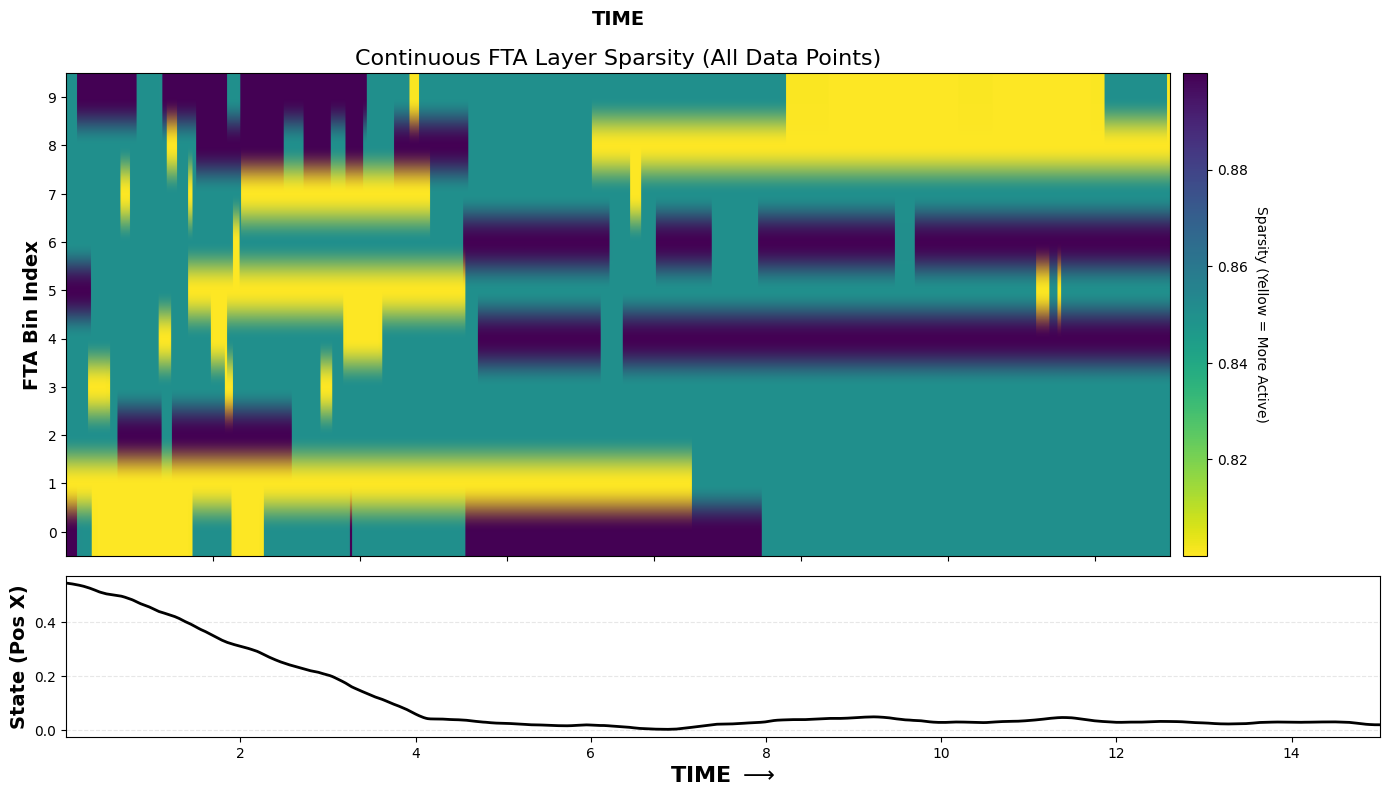

In [ ]:
def plot_continuous_fta_spectrogram(all_episode_bins_sparsity, all_episode_time, all_episodes_state, ep_idx=0):
    # 1. Data Prep
    # bins_data shape: (10, Timesteps) - we transpose to put bins on Y-axis
    bins_data = np.array(all_episode_bins_sparsity[ep_idx]).T 
    times = np.array(all_episode_time[ep_idx])
    states = np.array(all_episodes_state[ep_idx])[:, 0] # X-position

    # 2. Create Figure
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True, 
                                   gridspec_kw={'height_ratios': [3, 1]})

    # --- Top Plot: FTA Bin Sparsity Heatmap ---
    # This is "All Data" - every bin, every timestep
    im = ax1.imshow(bins_data, aspect='auto', origin='lower', 
                   extent=[times.min(), times.max(), -0.5, 9.5],
                   cmap='viridis_r') # reversed viridis: yellow = active
    
    ax1.set_ylabel("FTA Bin Index", fontsize=14, fontweight='bold')
    ax1.set_yticks(range(10))
    ax1.set_title("Continuous FTA Layer Sparsity (All Data Points)", fontsize=16)
    
    # Add a colorbar
    cbar = fig.colorbar(im, ax=ax1, pad=0.01)
    cbar.set_label('Sparsity (Yellow = More Active)', rotation=270, labelpad=15)

    # --- Bottom Plot: Agent State ---
    ax2.plot(times, states, color='black', lw=2, label='Agent X-Pos')
    ax2.set_ylabel("State (Pos X)", fontsize=14, fontweight='bold')
    ax2.set_xlabel("TIME $\longrightarrow$", fontsize=16, fontweight='bold')
    ax2.grid(axis='y', linestyle='--', alpha=0.3)

    # Styling to match your reference arrows
    ax1.annotate('', xy=(times.max(), 10), xytext=(times.min(), 10),
                 arrowprops=dict(arrowstyle='->', lw=2, color='black'), clip_on=False)
    ax1.text(np.mean(times), 10.5, "TIME", ha='center', fontweight='bold', fontsize=14)

    plt.tight_layout()
    plt.show()

# Execution
# plot_continuous_fta_spectrogram(all_episode_bins_sparsity, all_episode_time, all_episodes_state)

<>:20: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:20: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\l'
/var/folders/bm/8wy6w6fs4rx3vlh4d8m7h7200000gn/T/ipykernel_22024/2625490014.py:20: SyntaxWarning: invalid escape sequence '\l'
  fig.text(0.5, 0.04, 'TIME $\longrightarrow$', ha='center', fontsize=20, fontweight='bold')
/var/folders/bm/8wy6w6fs4rx3vlh4d8m7h7200000gn/T/ipykernel_22024/2625490014.py:21: SyntaxWarning: invalid escape sequence '\l'
  fig.text(0.02, 0.5, '$\longleftarrow$ STATE', va='center', rotation='vertical', fontsize=20, fontweight='bold')


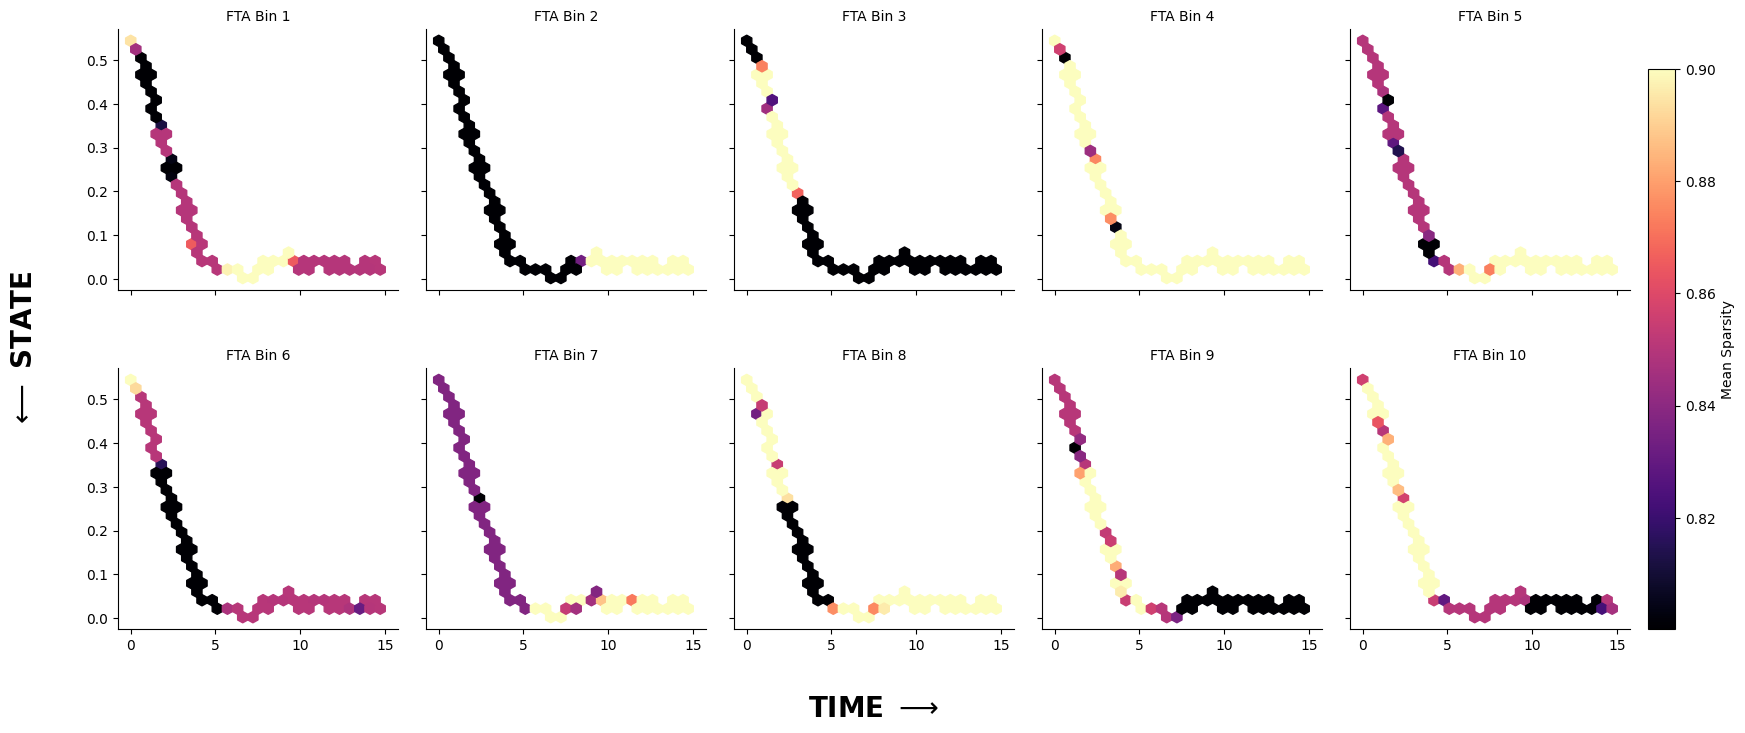

In [ ]:
def plot_all_bins_continuous_grid(all_episode_bins_sparsity, all_episode_time, all_episodes_state, ep_idx=0):
    bins_data = np.array(all_episode_bins_sparsity[ep_idx]) # (T, 10)
    times = np.array(all_episode_time[ep_idx])
    states = np.array(all_episodes_state[ep_idx])[:, 0]
    
    fig, axes = plt.subplots(2, 5, figsize=(18, 8), sharex=True, sharey=True)
    axes = axes.flatten()
    
    for i in range(10):
        ax = axes[i]
        # Use hexbin to aggregate "all data" into a continuous-looking surface
        hb = ax.hexbin(times, states, C=bins_data[:, i], gridsize=25, cmap='magma', reduce_C_function=np.mean)
        ax.set_title(f"FTA Bin {i+1}", fontsize=10)
        
        # Clean axes
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # Global Labels
    fig.text(0.5, 0.04, 'TIME $\longrightarrow$', ha='center', fontsize=20, fontweight='bold')
    fig.text(0.02, 0.5, '$\longleftarrow$ STATE', va='center', rotation='vertical', fontsize=20, fontweight='bold')
    
    # Global Colorbar
    cb_ax = fig.add_axes([0.93, 0.15, 0.015, 0.7])
    fig.colorbar(hb, cax=cb_ax, label='Mean Sparsity')
    
    plt.subplots_adjust(left=0.08, right=0.92, bottom=0.15, top=0.9, wspace=0.1, hspace=0.3)
    plt.show()

# Execution
# plot_all_bins_continuous_grid(all_episode_bins_sparsity, all_episode_time, all_episodes_state)

In [19]:
env, ag, placecells, actor, critic = create_experiment(dt=0.01,fta_eta=0.01, t_timeout=15)

 fta_eta: 0.01, n_tilings: 1, n_tiles: 10


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/ratinabox/utils.py:837: UserWarning: Cannot collect the default_params dictionaries, as Actor does not have the class attribute 'default_params' defined in its preamble. (Can be just an empty dictionary, i.e.: default_params = dict().)
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/ratinabox/utils.py:892: UserWarning: Cannot check the keys in the params dictionary, as <class 'base_actor_critic.Actor'> does not have a class attribute 'default_params' defined in its preamble. (Can be just an empty dictionary, i.e.: default_params = dict().)
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/ratinabox/utils.py:837: UserWarning: Cannot collect the default_params dictionaries, as Critic does not have the class attribute 'default_params' defined in its preamble. (Can be just an empty dictionary, i.e.: default_params = 

In [20]:
fta = find_fta_module(critic.NeuralNetworkModule)
all_episode_sparsity, all_episode_time, all_episodes_state, all_episode_bins_sparsity = run_multiple_episodes_with_fta(n_episodes=50, env=env, ag=ag, actor=actor, critic=critic, placecells=placecells, fta=fta)
# save_episode_data("timeout_15_dt_0.01_eta_0.01_.pkl", all_episode_sparsity, all_episode_time, all_episodes_state, all_episode_bins_sparsity)

# for i in range(len(all_episode_sparsity)):
#     print(f"Episode {i+1}:")
#     print(f"  Sparsity values: {len(all_episode_sparsity[i])}")
#     print(f"  Time steps: {len(all_episode_time[i])}")
#     print(f"  Agent states: {len(all_episodes_state[i])}")
#     print(f"  FTA bins sparsity: {len(all_episode_bins_sparsity[i])}")


<success fraction>: 0.02, <episode time> 14.7: 100%|██████████| 50/50 [01:35<00:00,  1.91s/it]


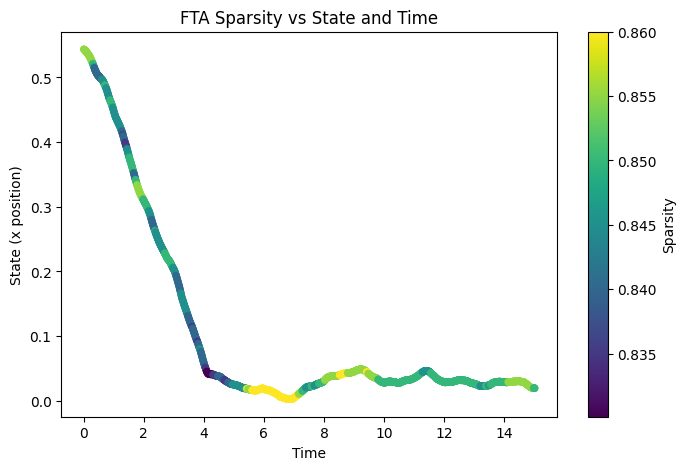

In [21]:
plot_sparsity_state_time_continuous(all_episode_sparsity[0], all_episode_time[0], all_episodes_state[0])

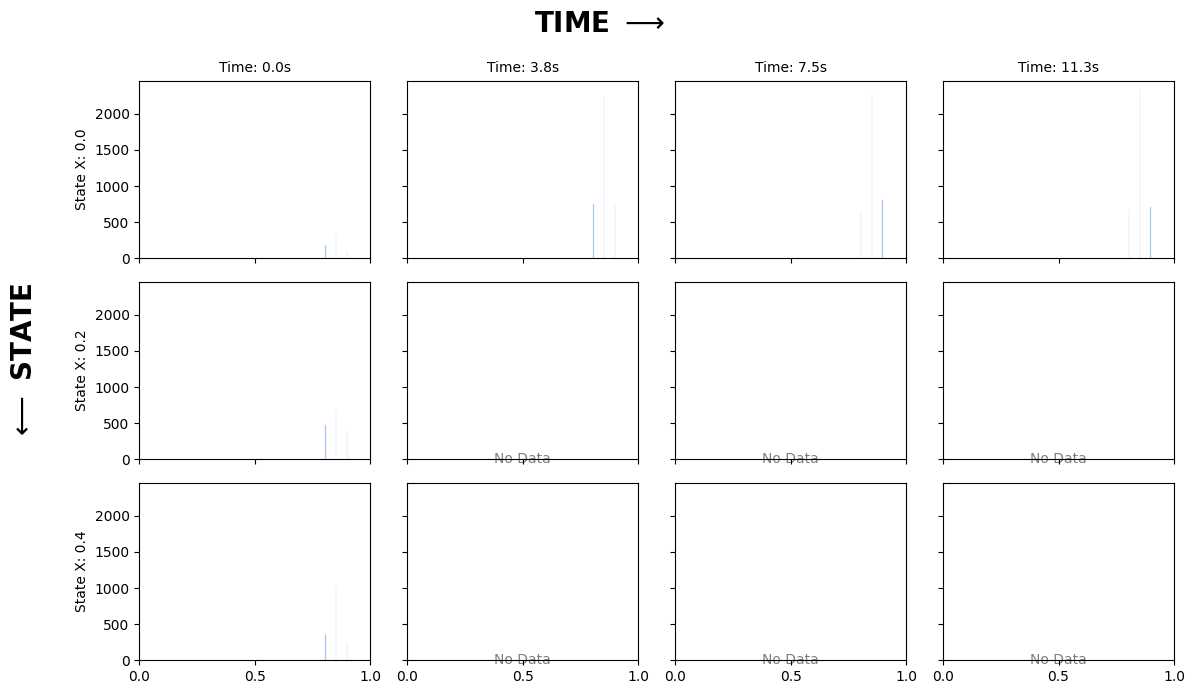

In [24]:
# Run the plot
plot_spatiotemporal_hist_grid(all_episode_bins_sparsity, all_episode_time, all_episodes_state, t_bins=4, s_bins=3)

In [30]:
print(all_episodes_state[0])

[array([0.5448293 , 0.69408266]), array([0.54586963, 0.69459859]), array([0.54684882, 0.69508749]), array([0.5478459 , 0.69563728]), array([0.54879559, 0.69618211]), array([0.54964194, 0.69671004]), array([0.55042138, 0.69721088]), array([0.55119008, 0.69771934]), array([0.55205688, 0.69829386]), array([0.55289429, 0.69888889]), array([0.55375958, 0.69946918]), array([0.55444543, 0.6999627 ]), array([0.55509202, 0.70043946]), array([0.55574537, 0.70095313]), array([0.55635131, 0.70150922]), array([0.5569238 , 0.70205539]), array([0.55746919, 0.70261509]), array([0.55794633, 0.70312751]), array([0.55842735, 0.70371109]), array([0.55896817, 0.70436611]), array([0.55947434, 0.7050101 ]), array([0.56003749, 0.70573158]), array([0.56056265, 0.70639122]), array([0.56107662, 0.7070713 ]), array([0.56163339, 0.70785619]), array([0.5621825 , 0.70861448]), array([0.56278211, 0.70938923]), array([0.56336524, 0.71012689]), array([0.56400884, 0.7109332 ]), array([0.56463471, 0.71168846]), array([0.

In [66]:
env.episodes

{'episode': [1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51],
 'start': [0,
  50.00000000000044,
  100.09999999999859,
  150.19999999999575,
  200.2999999999929,
  220.89999999999173,
  270.8999999999931,
  281.7999999999956,
  331.80000000000695,
  332.9000000000072,
  365.0000000000145,
  372.70000000001625,
  393.700000000021,
  443.7000000000324,
  493.70000000004376,
  543.7000000000551,
  593.7000000000664,
  643.7000000000778,
  693.7000000000892,
  743.7000000001005,
  793.7000000001119,
  843.7000000001233,
  893.7000000001347,
  943.700000000146,
  993.7000000001574,
  1043.8000000001462,
  1093.9000000001006,
  1144.000000000055,
  1194.1000000000095,
  1244.199999999964,
  1294.2999999999183,
  1344.3999999998728,
  1394.4999999998

    • To AUTOMATICALLY save all plots (recommended), set  `ratinabox.autosave_plots = True`
    • To MANUALLY save plots, call                        `ratinabox.utils.save_figure(figure_object, save_title).
      This warning will not be shown again
HINT: You can stylize plots to make them look like repo/paper by calling `ratinabox.stylize_plots()`
      This hint will not be shown again


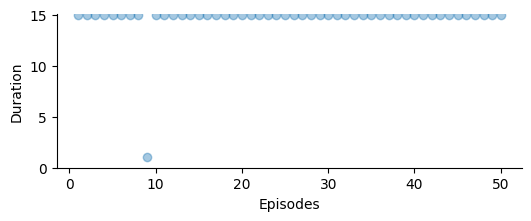

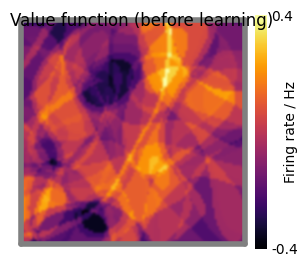

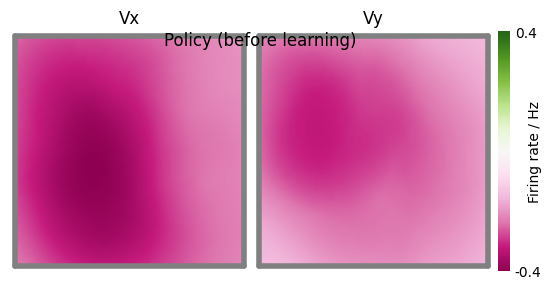

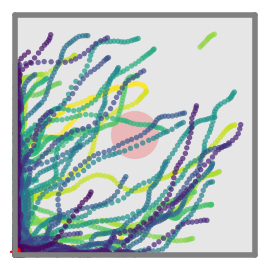

In [25]:
plot_rate_maps(env,ag,actor, critic,reward=True,trajectory=True)

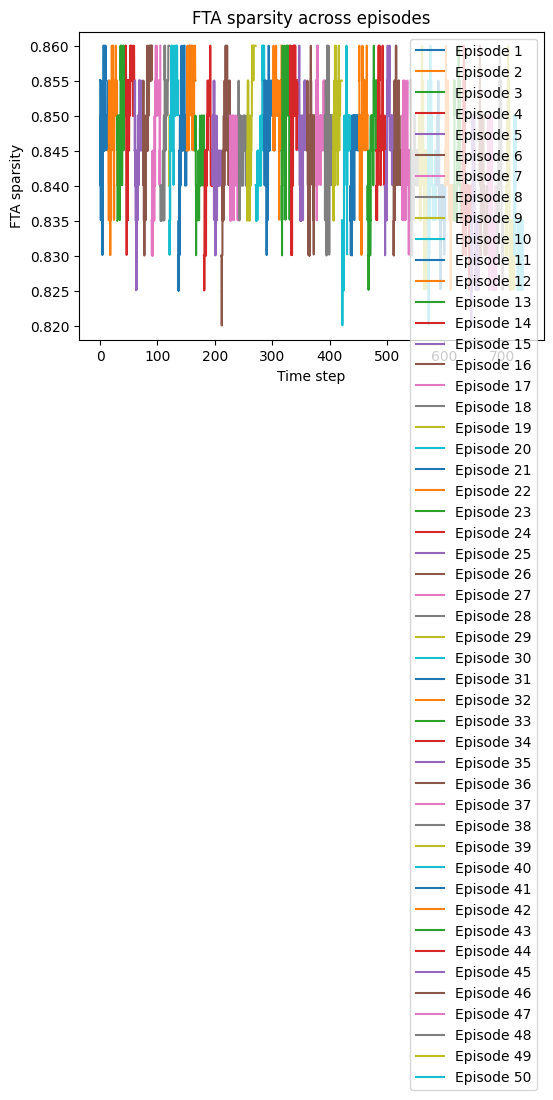

In [26]:
plot_sparsity_over_episodes(all_episode_sparsity, all_episode_time)

 fta_eta: 1, n_tilings: 1, n_tiles: 10


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/ratinabox/utils.py:837: UserWarning: Cannot collect the default_params dictionaries, as Actor does not have the class attribute 'default_params' defined in its preamble. (Can be just an empty dictionary, i.e.: default_params = dict().)
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/ratinabox/utils.py:892: UserWarning: Cannot check the keys in the params dictionary, as <class 'base_actor_critic.Actor'> does not have a class attribute 'default_params' defined in its preamble. (Can be just an empty dictionary, i.e.: default_params = dict().)
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/ratinabox/utils.py:837: UserWarning: Cannot collect the default_params dictionaries, as Critic does not have the class attribute 'default_params' defined in its preamble. (Can be just an empty dictionary, i.e.: default_params = 

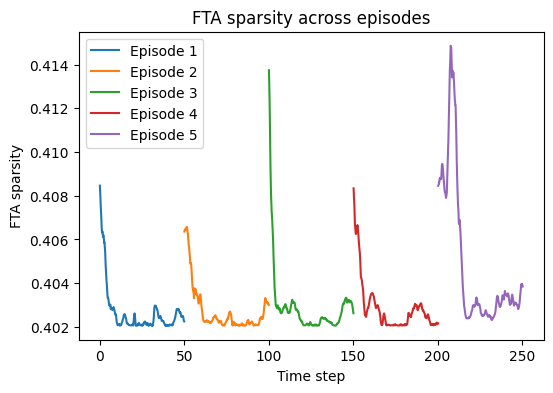

In [ ]:
env, ag, placecells, actor, critic = create_experiment(dt=0.01, fta_eta=1)
all_episode_sparsity, all_episode_time,all_episode_state = run_multiple_episodes_with_fta(n_episodes=N_EPISODES, env=env, ag=ag, actor=actor, critic=critic, placecells=placecells, fta=find_fta_module(critic.NeuralNetworkModule))
save_episode_data("timeout_15_dt_0.01_eta_1_.pkl", all_episode_sparsity, all_episode_time, all_episodes_state, all_episode_bins_sparsity)
print(env.episodes)
plot_sparsity_over_episodes(all_episode_sparsity, all_episode_time)


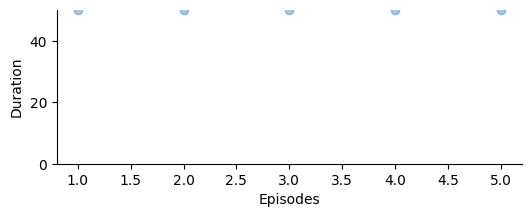

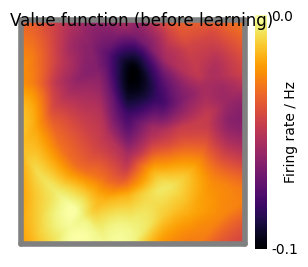

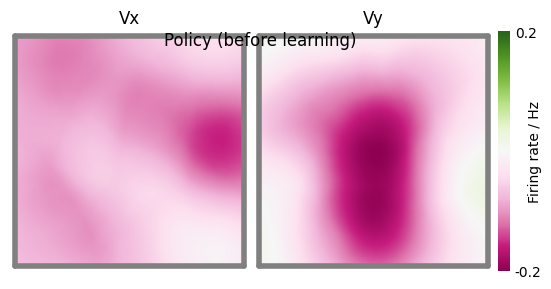

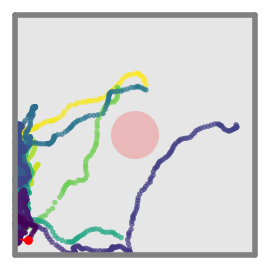

In [ ]:
plot_rate_maps(env, ag, actor, critic, reward=True, trajectory=True)